# Car Classification Model Training

*This notebook implements custom models based on the approach described in the paper: [EfficientNet with Hybrid Attention Mechanisms for Enhanced Breast Histopathology Classification: A Comprehensive Approach](https://arxiv.org/pdf/2410.22392v2).* 

This notebook demonstrates the full pipeline for training and evaluating deep learning models for Indonesian car type classification using a custom dataset. The workflow includes dataset preparation, model training with class imbalance handling, evaluation, and visualization of results.

### Dataset Overview
- **Source**: The dataset was collected using a custom web scraper (see the notebook `1_run_scraper_into_dataset`) to gather Indonesian car images from various sources.
- **Final Dataset**: The cleaned and organized dataset is available at [Kaggle: indonesian-cars-classification-dataset](https://www.kaggle.com/datasets/muhammadluthfiarifin/indonesian-cars-classification-dataset).
- **Structure**: The dataset is split into train, validation, and test sets, each containing images for 8 car classes.

### Model Used
- **EfficientNetB4-CBAM**: Uses EfficientNet-B4 as the backbone and integrates Convolutional Block Attention Module (CBAM) blocks to enhance feature representation and improve classification performance.

### Overview
- **Classes**: 8 Indonesian car types (hatchback, mpv, offroad, pickup, sedan, suv, truck, van)
- **Training Strategy**: Transfer learning, data augmentation, and weighted loss for class imbalance
- **Evaluation**: Per-class metrics, confusion matrix, and visualizations

### Clone Model Code Repository

In [9]:
!rm -rf /kaggle/working/*
!git clone -b test/vanilla https://github.com/luthfiarifin/hybrid-envit-car-retrieval.git code
!mv code/* .
!ls

Cloning into 'code'...
remote: Enumerating objects: 295, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 295 (delta 7), reused 16 (delta 4), pack-reused 271 (from 2)
Receiving objects: 100% (295/295), 574.19 MiB | 5.73 MiB/s, done.
Resolving deltas: 100% (108/108), done.
Updating files: 100% (76/76), done.
1_run_scraper_into_dataset.ipynb	docs
2_finetune_the_detection_model.ipynb	logs
3_train_the_classification_model.ipynb	models
4_final_traffic_cam_test.ipynb		readme.md
app_test.py				requirements.txt
code					traffic_test_classified.mp4
data_processing				traffic_test.mp4


### Download and Prepare Dataset

In [10]:
IS_IMPORT_FROM_KAGGLE = True

if IS_IMPORT_FROM_KAGGLE:
    import kagglehub
    DATASET_DIR = kagglehub.dataset_download("muhammadluthfiarifin/indonesian-cars-classification-dataset", path="dataset")
else:
    DATASET_DIR = "data_processing/data/dataset"

### Import Libraries and Check Environment

In [11]:
# Import required libraries

import torch
import time
from datetime import datetime

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(
        f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB"
    )

Libraries imported successfully!
PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: Tesla P100-PCIE-16GB
CUDA memory: 15.9 GB


### Configure Training and Explore Dataset

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


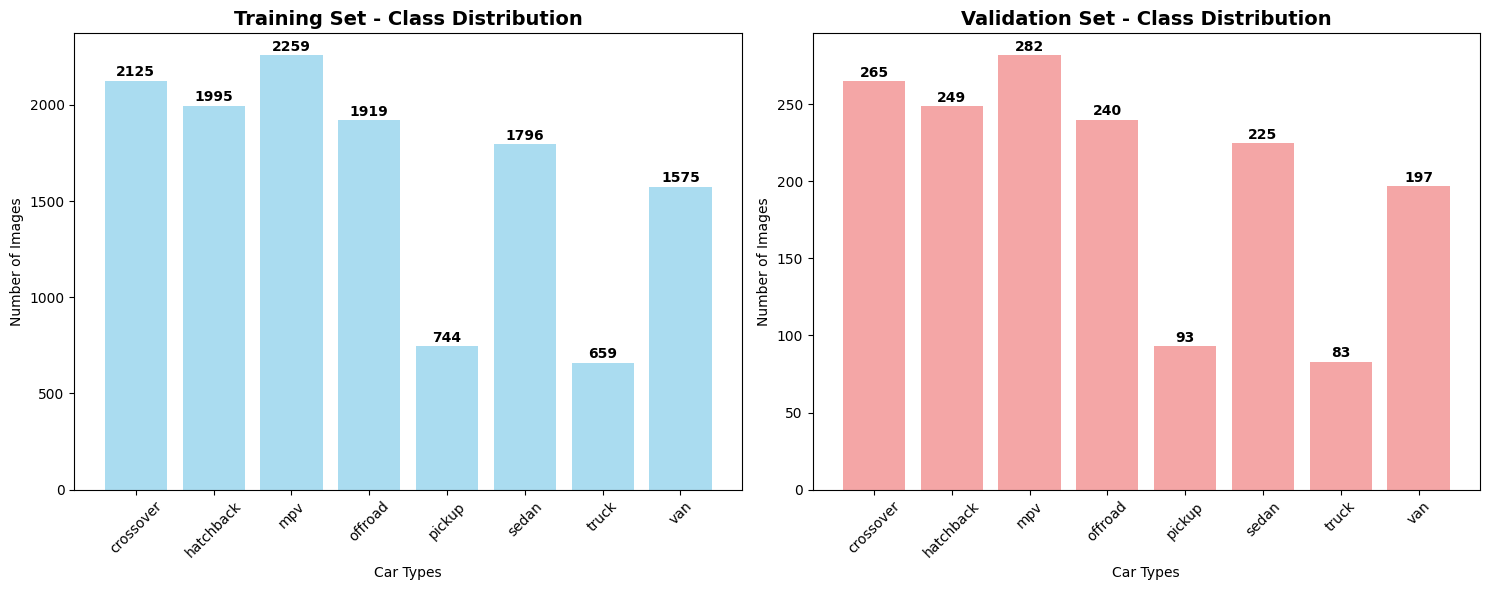


=== Initializing Trainer with Class Imbalance Handling & Early Stopping ===
Using device: cuda
Logging to TensorBoard: logs/train_classification/run_1751418330


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Using standard CrossEntropyLoss

📊 Class Distribution Analysis:
Class        Count    Percentage Imbalance Ratio
--------------------------------------------------
crossover    2125     16.3      % 1.06           x
hatchback    1995     15.3      % 1.13           x
mpv          2259     17.3      % 1.00           x
offroad      1919     14.7      % 1.18           x
pickup       744      5.7       % 3.04           x
sedan        1796     13.7      % 1.26           x
truck        659      5.0       % 3.43           x
van          1575     12.0      % 1.43           x

📈 Imbalance Factor: 3.43x (Most frequent / Least frequent)
⚠️  Moderate imbalance detected. Weighted loss recommended.
Trainer initialized successfully!
Training samples: 13072
Validation samples: 1634
Number of batches per epoch: 205
Class names: ['crossover', 'hatchback', 'mpv', 'offroad', 'pickup', 'sedan', 'truck', 'van']


In [12]:
# Training configuration

from models.classification.train_classification import CarClassifierTrainer
from models.classification.train_classification_eval import DatasetExplorer


CONFIG = {
    "train_dir": f"{DATASET_DIR}/train",
    "val_dir": f"{DATASET_DIR}/val",
    "num_classes": 8,
    "learning_rate": 1e-4,
    "batch_size": 64,
    "num_epochs": 50,
    "result_path": f'models/classification/results/car_classifier_model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.pth',
    "use_weighted_loss": False,
    "use_class_balancing": False,
    "num_workers": 8,
    "early_stopping_patience": 7,
    "early_stopping_delta": 0.001,
    "early_stopping_verbose": True,
    "pretrained": True,
    "vanilla": True,
}

# Generate and summary report
explorer = DatasetExplorer(
    train_dir=CONFIG["train_dir"],
    val_dir=CONFIG["val_dir"],
)
explorer.summary_report()

# Initialize the trainer
print("\n=== Initializing Trainer with Class Imbalance Handling & Early Stopping ===")
trainer = CarClassifierTrainer(
    train_dir=CONFIG["train_dir"],
    val_dir=CONFIG["val_dir"],
    num_classes=CONFIG["num_classes"],
    learning_rate=CONFIG["learning_rate"],
    batch_size=CONFIG["batch_size"],
    num_epochs=CONFIG["num_epochs"],
    result_path=CONFIG["result_path"],
    use_weighted_loss=CONFIG["use_weighted_loss"],
    use_class_balancing=CONFIG["use_class_balancing"],
    num_workers=CONFIG["num_workers"],
    early_stopping_patience=CONFIG["early_stopping_patience"],
    early_stopping_delta=CONFIG["early_stopping_delta"],
    early_stopping_verbose=CONFIG["early_stopping_verbose"],
    pretrained=CONFIG["pretrained"],
    vanilla=CONFIG["vanilla"],
)

print("Trainer initialized successfully!")
print(f"Training samples: {len(trainer.train_dataset)}")
print(f"Validation samples: {len(trainer.val_dataset)}")
print(f"Number of batches per epoch: {len(trainer.train_loader)}")
print(f"Class names: {trainer.train_dataset.classes}")

### Train the Model

In [13]:
# Start training with detailed tracking
start_time = time.time()

# Execute training
training_results = trainer.train()

# Print training results
total_time = time.time() - start_time
print(f"\n=== Training Completed in {total_time:.2f} seconds ===")

Starting training with detailed tracking and early stopping...
Early Stopping - Patience: 7, Delta: 0.001
Model parameters: 17,562,960
Trainable parameters: 17,562,960

Epoch 1/50


100%|██████████| 205/205 [02:53<00:00,  1.18it/s, loss=1.62]


Validation accuracy: 46.51%
Validation loss: 1.3929
Train Loss: 1.8647 | Train Acc: 29.87%
Val Loss: 1.3929 | Val Acc: 46.51%
Time: 186.40s | LR: 1.00e-04
🎉 New best accuracy: 46.51%
Validation loss decreased (inf --> 1.392916).  Saving model ...

Epoch 2/50


100%|██████████| 205/205 [02:52<00:00,  1.19it/s, loss=1.83] 


Validation accuracy: 62.61%
Validation loss: 1.0367
Train Loss: 1.3315 | Train Acc: 49.50%
Val Loss: 1.0367 | Val Acc: 62.61%
Time: 180.88s | LR: 1.00e-04
🎉 New best accuracy: 62.61%
Validation loss decreased (1.392916 --> 1.036657).  Saving model ...

Epoch 3/50


...

Validation accuracy: 87.39%
Validation loss: 0.4360
Train Loss: 0.1681 | Train Acc: 93.64%
Val Loss: 0.4360 | Val Acc: 87.39%
Time: 211.87s | LR: 1.00e-04
EarlyStopping counter: 5 out of 7

Epoch 21/50


100%|██████████| 205/205 [03:15<00:00,  1.05it/s, loss=0.316] 


Validation accuracy: 87.27%
Validation loss: 0.4302
Train Loss: 0.1640 | Train Acc: 93.72%
Val Loss: 0.4302 | Val Acc: 87.27%
Time: 205.83s | LR: 1.00e-04
EarlyStopping counter: 6 out of 7

Epoch 22/50


100%|██████████| 205/205 [03:10<00:00,  1.07it/s, loss=0.312] 


Validation accuracy: 87.82%
Validation loss: 0.4138
Train Loss: 0.1588 | Train Acc: 94.09%
Val Loss: 0.4138 | Val Acc: 87.82%
Time: 201.65s | LR: 1.00e-04
EarlyStopping counter: 7 out of 7

🛑 Early stopping triggered at epoch 22
Best validation loss: 0.405384

Training completed!
Training stopped early at epoch 22 due to no improvement in validation loss
Best validation accuracy: 87.94%
Loading best model with validation loss: 0.405384
Best accuracy model saved to models/classification/results/car_classifier_model_20250702_010529_best_acc.pth

=== Training Completed in 4425.41 seconds ===


### Evaluate Model and Generate Report

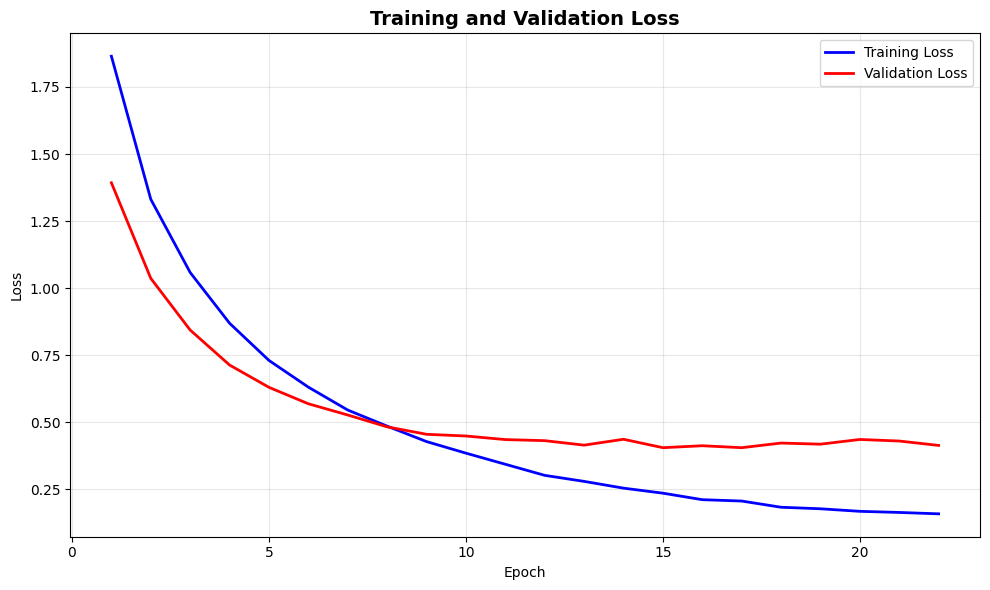

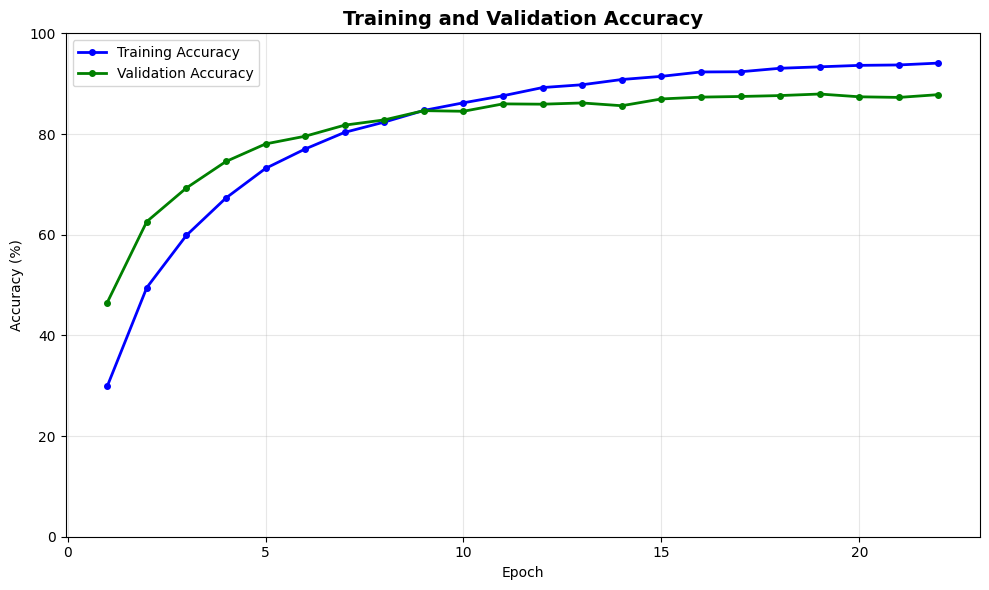

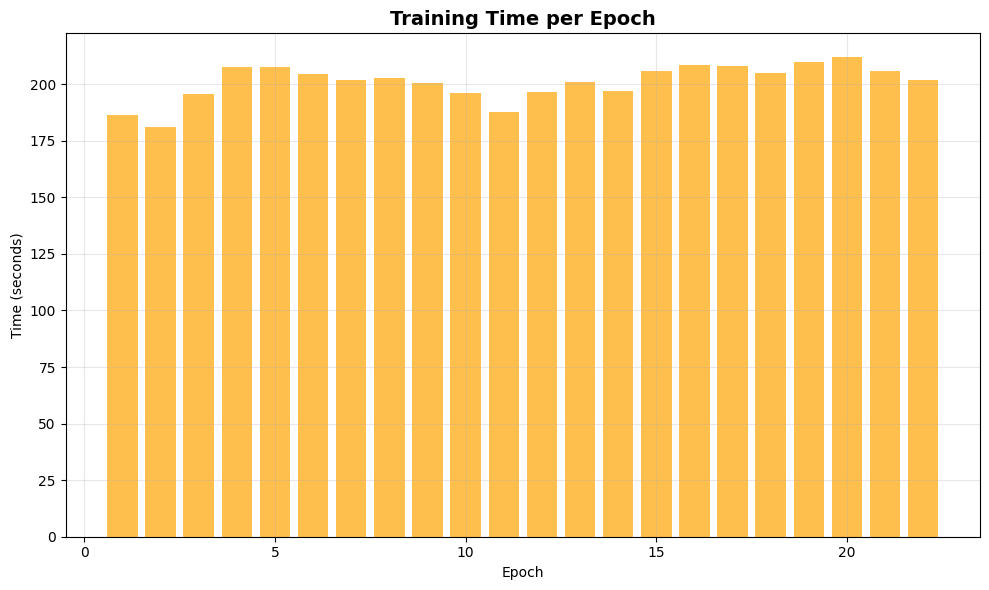

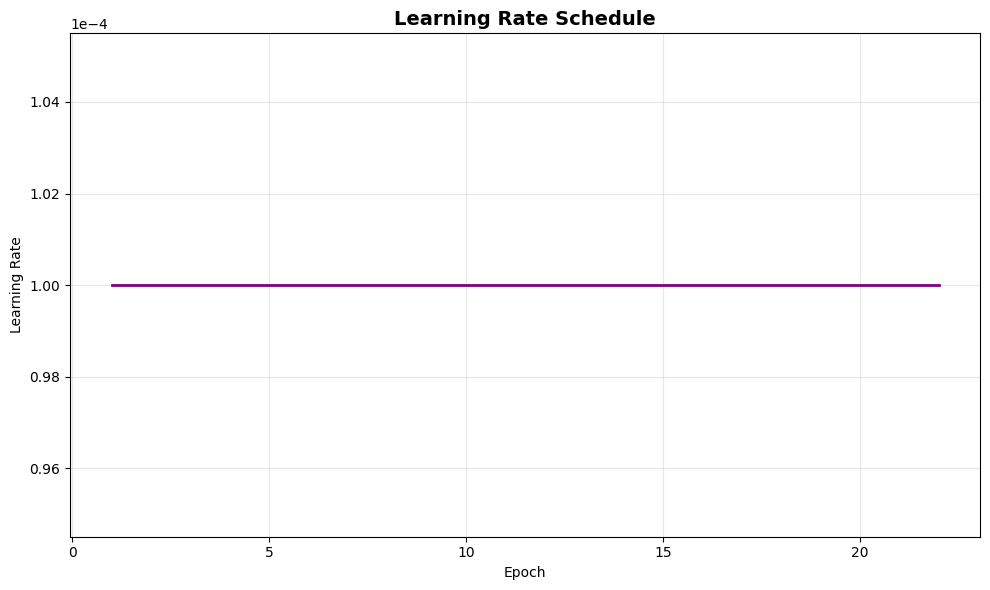

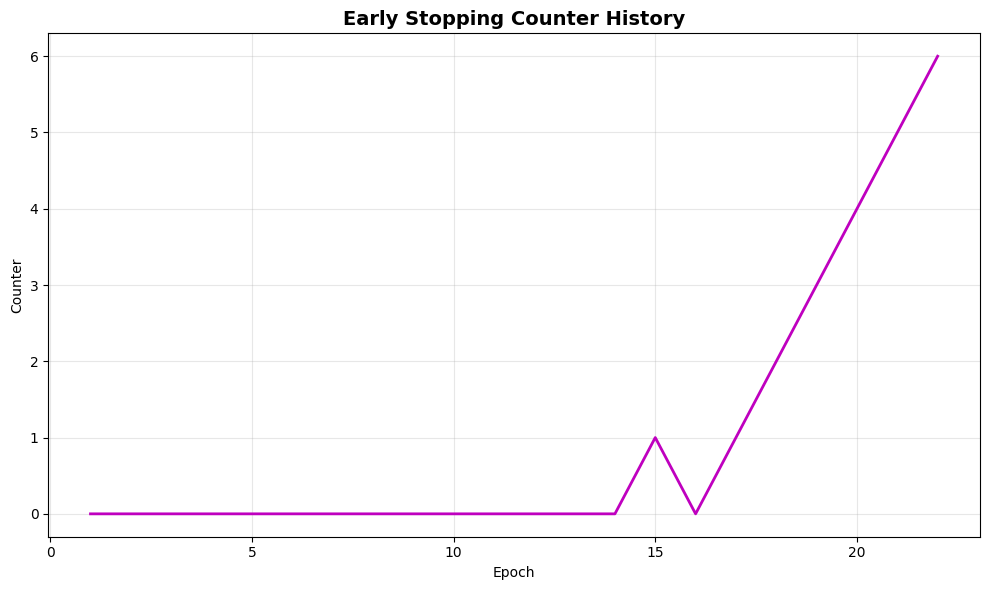


🛑 Early Stopping Analysis:
Early stopping triggered at epoch 22/50.
Epochs saved: 28
Time saved: ~93.8 minutes
Efficiency gain: 56.0%

📈 Detailed Training Statistics:
- Loss Reduction: 1.8647 → 0.1588 (91.5% improvement)
- Best Accuracy: 87.94% (Epoch 19)
- Total Training Time: 73.70 minutes
- Average Time per Epoch: 201.01s
- Fastest Epoch: 180.88s
- Slowest Epoch: 211.87s
- Early Stopping Counter History: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 3, 4, 5, 6]

📋 Training Metrics Table (Last 5 Epochs):
 Epoch  Train_Loss  Val_Loss  Val_Accuracy  Epoch_Time  Learning_Rate  ES_Counter
    18      0.1834    0.4226         87.64      204.94         0.0001           2
    19      0.1777    0.4185         87.94      209.87         0.0001           3
    20      0.1681    0.4360         87.39      211.87         0.0001           4
    21      0.1640    0.4302         87.27      205.83         0.0001           5
    22      0.1588    0.4138         87.82      201.65         0.000

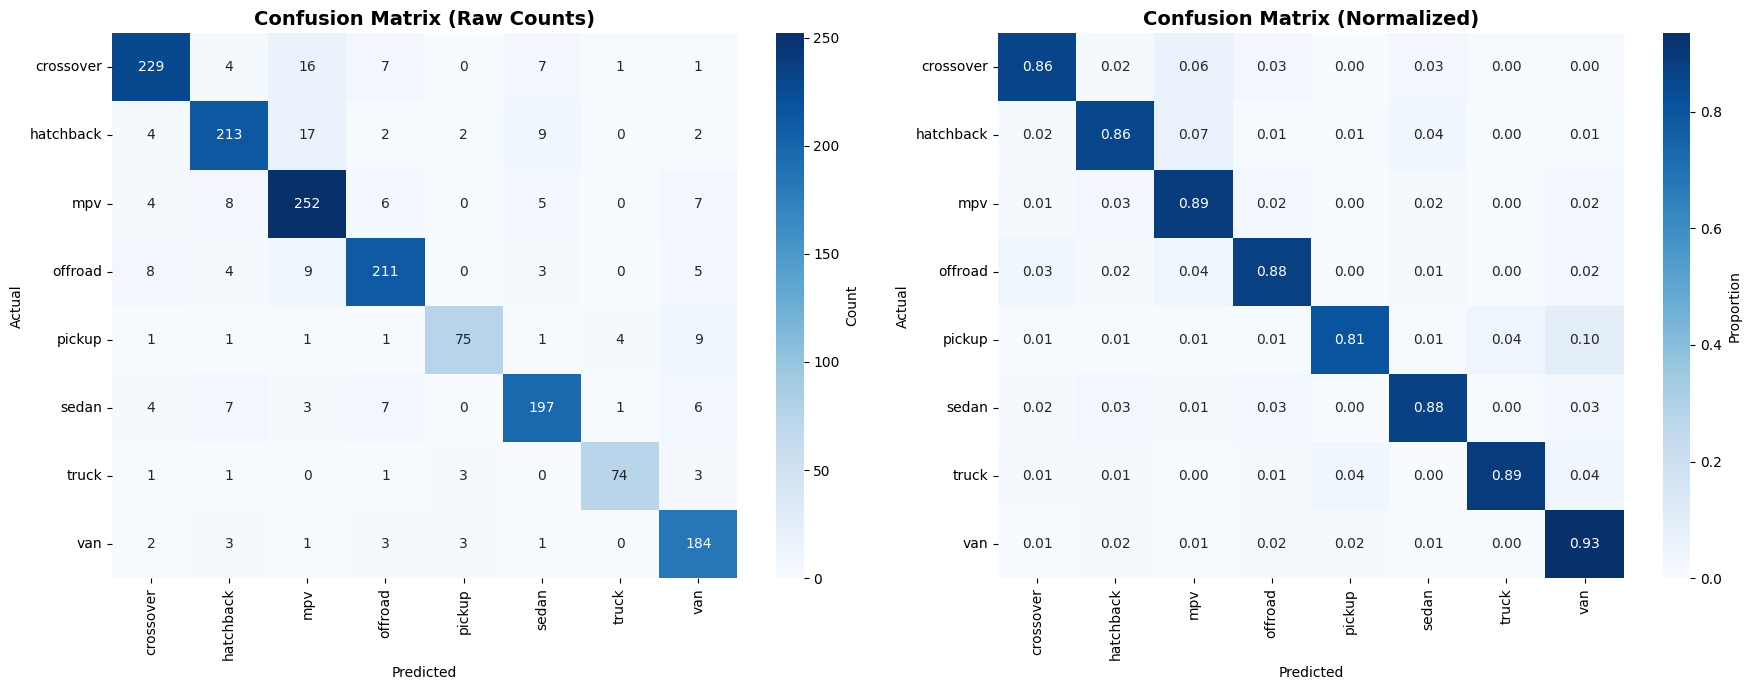


📊 Detailed Classification Report:
              precision    recall  f1-score   support

   crossover     0.9051    0.8642    0.8842       265
   hatchback     0.8838    0.8554    0.8694       249
         mpv     0.8428    0.8936    0.8675       282
     offroad     0.8866    0.8792    0.8828       240
      pickup     0.9036    0.8065    0.8523        93
       sedan     0.8834    0.8756    0.8795       225
       truck     0.9250    0.8916    0.9080        83
         van     0.8479    0.9340    0.8889       197

    accuracy                         0.8782      1634
   macro avg     0.8848    0.8750    0.8791      1634
weighted avg     0.8794    0.8782    0.8782      1634


⚖️ Class Imbalance Impact Analysis:

📈 Class Group Performance:
Minority Classes (4): ['pickup', 'sedan', 'truck', 'van']
Average Accuracy: 87.69%
Majority Classes (4): ['crossover', 'hatchback', 'mpv', 'offroad']
Average Accuracy: 87.31%
Performance Gap: 0.38% (Minority better)


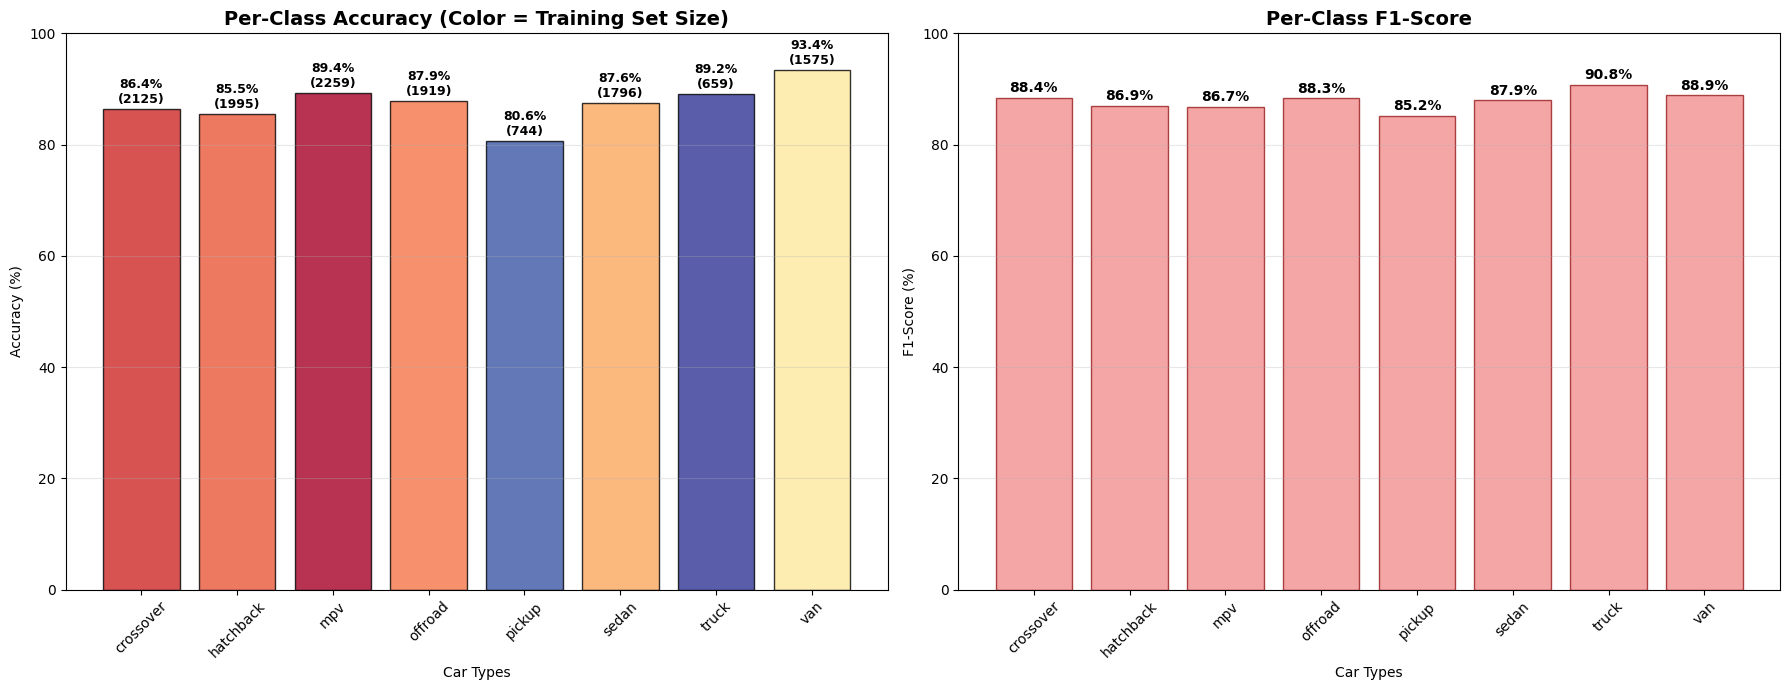


🛑 Early stopping summary saved to: models/classification/reports/early_stopping_summary_20250702_022204.json

💾 Training history saved to: models/classification/reports/training_history_20250702_022204.csv
📊 Class performance saved to: models/classification/reports/class_performance_20250702_022204.csv
🎯 Best model saved to: models/classification/results/car_classifier_model_20250702_010529.pth
🏆 Best accuracy model saved to: models/classification/results/car_classifier_model_20250702_010529_best_acc.pth

🎉 Training Analysis Complete!
🎯 Final Summary:
- Training completed in 22 epochs (planned: 50)
- Best validation accuracy: 87.94%
- Early stopping: Activated
- Total training time: 73.70 minutes
- Time saved by early stopping: 93.8 minutes
- Class imbalance: Moderate (ratio: 3.43x)
- Model saved with best validation loss: 0.405384


In [14]:
# Generate the full report
from models.classification.train_classification_eval import TrainingEvaluation

report = TrainingEvaluation(trainer, CONFIG, training_results)

report.full_report()

### Test the Trained Model

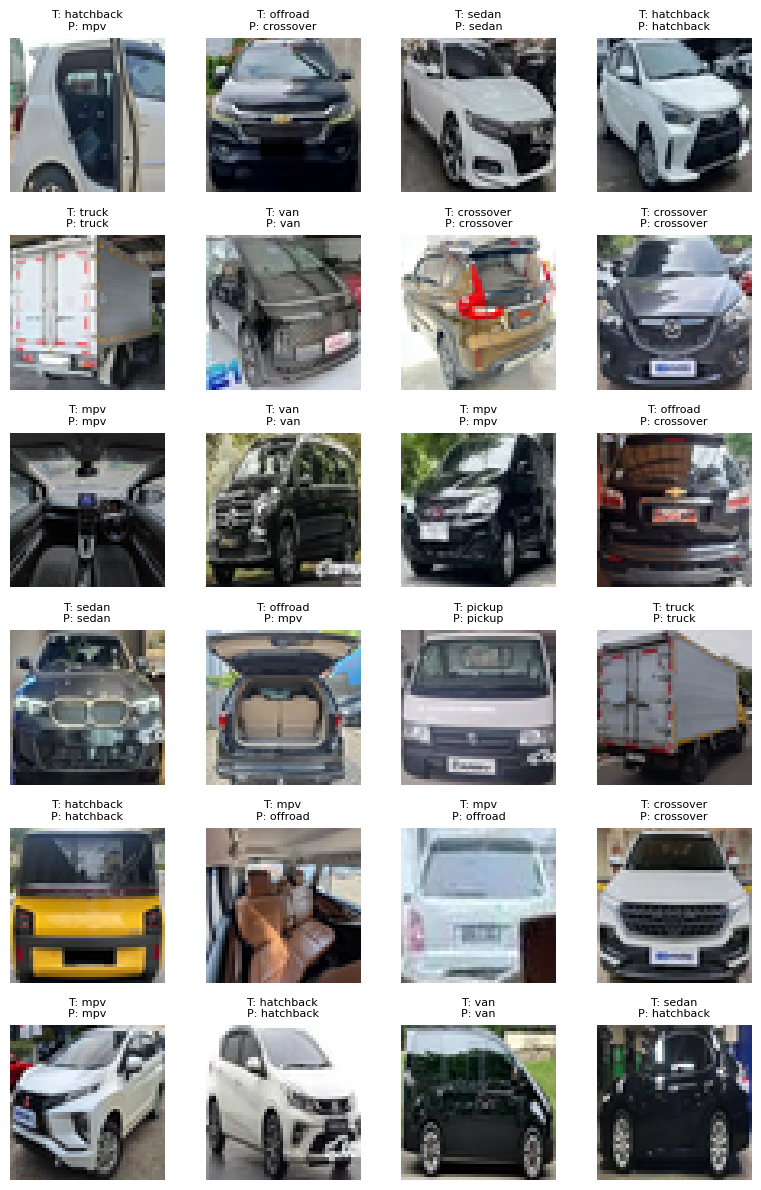

Test Accuracy: 70.83% (17/24)


In [15]:
# Test the classification model test images and display predictions
import os

from models.classification.test_classification import CarClassificationTester

test_dir = f"{DATASET_DIR}/test"
class_names = [
    d for d in sorted(os.listdir(test_dir)) if os.path.isdir(os.path.join(test_dir, d))
]
tester = CarClassificationTester(
    test_dir=test_dir,
    class_names=class_names,
    model_path=None,
    grid_rows=6,
    grid_cols=4,
    num_classes=CONFIG["num_classes"],
    vanilla=CONFIG["vanilla"],
)

tester.plot_predictions()